# Tokenization Papers

In [1]:
import paper_dataset
import pandas as pd
import importlib
import re
import matplotlib.pyplot as plt
importlib.reload(paper_dataset)

<module 'paper_dataset' from '/lnet/work/people/vico/TokSurvey/paper_dataset.py'>

In [2]:
df = paper_dataset.load()

## Samples and RE 

In [ ]:
samples = paper_dataset.sample(df, 5)
for s in samples.iloc:
    paper_dataset.print_sample(s)

Title: The Geometry of Numerical Reasoning: Language Models Compare Numeric Properties in Linear Subspaces
Author(s): El-Shangiti, Ahmed Oumar and Hiraoka, Tatsuya and AlQuabeh, Hilal and Heinzerling, Benjamin and Inui, Kentaro
Year: 2025
Venue: None (ACL)
Volume: Proceedings of the 2025 Conference of the Nations of the Americas Chapter of the Association for Computational Linguistics: Human Language Technologies (Volume 2: Short Papers)
--------------------------------------------------------------------------------
Abstract:
   This paper investigates whether large language models (LLMs) utilize
   numerical attributes encoded in a low-dimensional subspace of
   theembedding space when answering questions involving numeric
   comparisons, e.g., Was Cristiano born before Messi? We first
   identified,using partial least squares regression, these subspaces,
   which effectively encode the numerical attributes associated with the
   entities in comparison prompts. Further, we demonstrat

In [3]:
recent = df[df['year'] >= 2016]
keywords = re.compile(r"token|sub-?word|segment")
tokenization = recent[recent["abstract"].apply(lambda x: x is not None and re.search(keywords, x.lower()) is not None)]

print(f"Number of papers in the dataset: {len(df)}")
print(f"Number of papers since 2016: {len(recent)}")
print(f"Number of papers on tokenization since 2016: {len(tokenization)}")

Number of papers in the dataset: 149355
Number of papers since 2016: 101891
Number of papers on tokenization since 2016: 8266


In [ ]:
samples = paper_dataset.sample(tokenization, 3)
for s in samples.iloc:
    paper_dataset.print_sample(s)

Title: Spike-driven Transformer V2: Meta Spiking Neural Network Architecture Inspiring the Design of Next-generation Neuromorphic Chips
Author(s): Man Yao and JiaKui Hu and Tianxiang Hu and Yifan Xu and Zhaokun Zhou and Yonghong Tian and Bo XU and Guoqi Li
Year: 2024
Venue: ICLR 2024 poster (ICLR)
Volume: The Twelfth International Conference on Learning Representations
--------------------------------------------------------------------------------
Abstract:
   Neuromorphic computing, which exploits Spiking Neural Networks (SNNs) on
   neuromorphic chips, is a promising energy-efficient alternative to
   traditional AI. CNN-based SNNs are the current mainstream of
   neuromorphic computing. By contrast, no neuromorphic chips are designed
   especially for Transformer-based SNNs, which have just emerged, and
   their performance is only on par with CNN-based SNNs, offering no
   distinct advantage. In this work, we propose a general Transformer-based
   SNN architecture, termed as ``Met

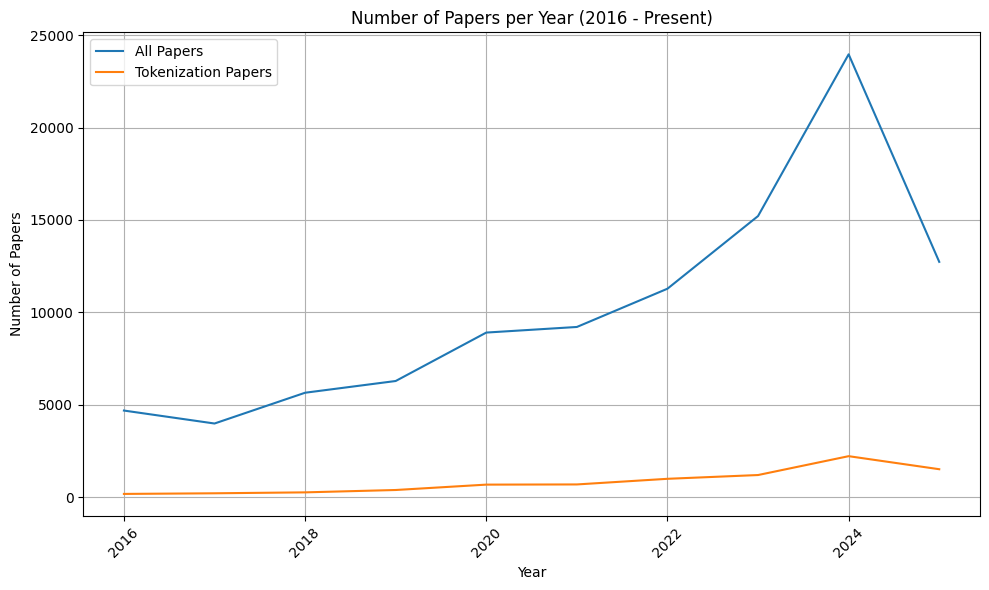

In [6]:
# Plot the number of papers per year
plt.figure(figsize=(10, 6))
recent_counts = recent['year'].value_counts().sort_index()
recent_counts.plot(kind="line")
tokenization_counts = tokenization['year'].value_counts().sort_index()
tokenization_counts.plot(kind="line")
plt.title('Number of Papers per Year (2016 - Present)')
plt.xlabel('Year')
plt.ylabel('Number of Papers')
plt.xticks(rotation=45)
plt.legend(['All Papers', 'Tokenization Papers'])
plt.grid(True)
plt.tight_layout()
plt.show()

## Filter with LLM and save the results

In [12]:
import tqdm
import llm_filter
import paper_dataset
import importlib
import matplotlib.pyplot as plt
import re
tqdm.tqdm.pandas()

In [ ]:
# tokenization['topic'] = tokenization.progress_apply(lambda x: llm_filter.filter_topic(x['abstract'], x['title']), axis=1)
# Merge the tokenization DataFrame with the original DataFrame adding the column 'topic' (bool)
# df = df.merge(tokenization[['bibtex_id', 'topic']], on='bibtex_id', how='left')
# Save df to jsonl file
# df.to_json('topic_papers_retry_ta_2shot.jsonl', orient='records', lines=True)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8266/8266 [1:01:39<00:00,  2.23it/s]
/COMP.TMP/vico_5779059/ipykernel_3487670/4142716666.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tokenization['topic'] = tokenization.progress_apply(lambda x: llm_filter.filter_topic(x['abstract'], x['title']), axis=1)


In [6]:
df = paper_dataset.load('data/topic_papers.jsonl')
recent = df[df['year'] >= 2016]
real_tokenization = df[df['topic'] == True]

In [7]:
samples = paper_dataset.sample(real_tokenization, 3)
for s in samples.iloc:
    paper_dataset.print_sample(s)

Title: {M}orfessor-enriched features and multilingual training for canonical morphological segmentation
Author(s): Rouhe, Aku and Gr{\"o}nroos, Stig-Arne and Virpioja, Sami and Creutz, Mathias and Kurimo, Mikko
Year: 2022
Venue: None (ACL)
Volume: Proceedings of the 19th SIGMORPHON Workshop on Computational Research in Phonetics, Phonology, and Morphology
--------------------------------------------------------------------------------
Abstract:
   In our submission to the SIGMORPHON 2022 Shared Task on Morpheme
   Segmentation, we study whether an unsupervised morphological
   segmentation method, Morfessor, can help in a supervised setting.
   Previous research has shown the effectiveness of the approach in
   semisupervised settings with small amounts of labeled data. The current
   tasks vary in data size: the amount of word-level annotated training
   data is much larger, but the amount of sentencelevel annotated training
   data remains small. Our approach is to pre-segment the in

In [13]:
recent = paper_dataset.load()
recent = recent[recent['year'] >= 2016]
keywords = re.compile(r"token|sub-?word|segment")
possible = recent[recent["abstract"].progress_apply(lambda x: x is not None and re.search(keywords, x.lower()) is not None)]

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 101891/101891 [00:01<00:00, 97636.93it/s]


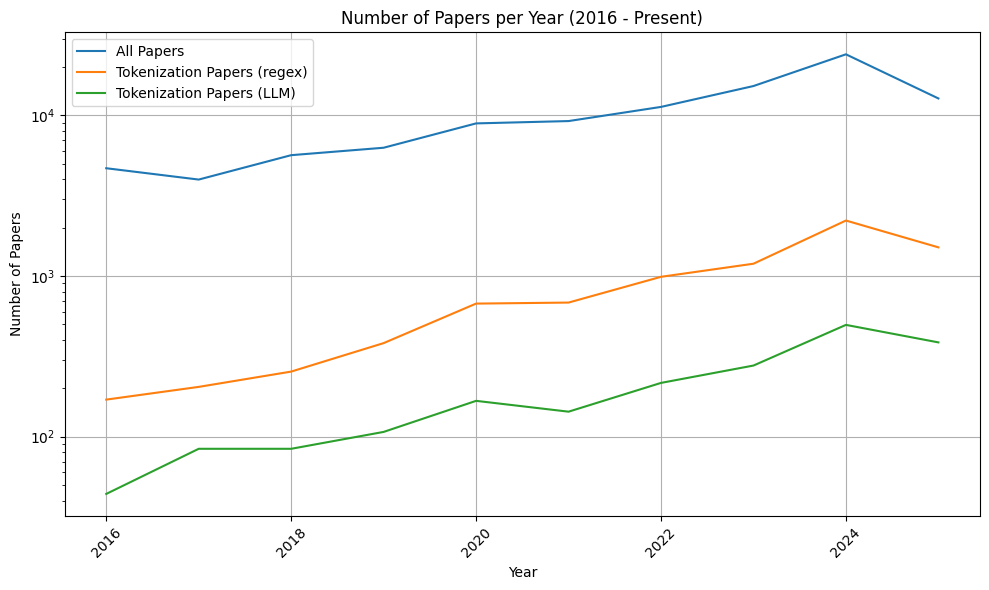

In [14]:
# Plot the number of papers per year
plt.figure(figsize=(10, 6))
recent_counts = recent['year'].value_counts().sort_index()
recent_counts.plot(kind="line", logy=True)
tokenization_counts = possible['year'].value_counts().sort_index()
tokenization_counts.plot(kind="line", logy=True)
real_tokenization_counts = real_tokenization['year'].value_counts().sort_index()
real_tokenization_counts.plot(kind="line", logy=True)
plt.title('Number of Papers per Year (2016 - Present)')
plt.xlabel('Year')
plt.ylabel('Number of Papers')
plt.xticks(rotation=45)
plt.legend(['All Papers', 'Tokenization Papers (regex)', 'Tokenization Papers (LLM)'])
plt.grid(True)
plt.tight_layout()
plt.show()

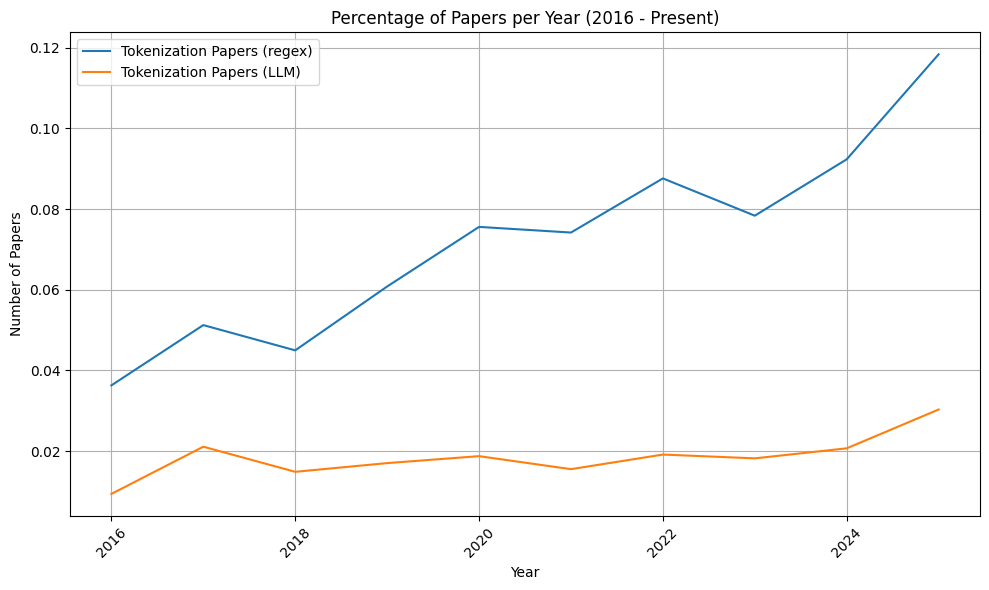

In [15]:
# Plot the number of papers per year
plt.figure(figsize=(10, 6))
recent_counts = recent['year'].value_counts().sort_index()
tokenization_counts = possible['year'].value_counts().sort_index()
(tokenization_counts / recent_counts).plot(kind="line")
real_tokenization_counts = real_tokenization['year'].value_counts().sort_index()
(real_tokenization_counts / recent_counts).plot(kind="line")
plt.title('Percentage of Papers per Year (2016 - Present)')
plt.xlabel('Year')
plt.ylabel('Number of Papers')
plt.xticks(rotation=45)
plt.legend(['Tokenization Papers (regex)', 'Tokenization Papers (LLM)'])
plt.grid(True)
plt.tight_layout()
plt.show()

## Type of the paper
- Tokeniser/Evaluation/Application/Other

In [16]:
import tqdm
import llm_filter
import paper_dataset
import importlib
import matplotlib.pyplot as plt
import re
tqdm.tqdm.pandas()

In [74]:
importlib.reload(llm_filter)

<module 'llm_filter' from '/lnet/work/people/vico/TokSurvey/llm_filter.py'>

In [ ]:
df = paper_dataset.load('data/topic_papers.jsonl')
real_tokenization = df[df['topic'] == True]
real_tokenization.shape

(2004, 14)

In [75]:
llm_filter.test('test_set.json', lambda a, t, c: llm_filter.is_tokeniser(a, t), 'tokenization')
llm_filter.test('test_set.json', lambda a, t, c: llm_filter.is_evaluation(a, t), 'evaluation')
llm_filter.test('test_set.json', lambda a, t, c: llm_filter.is_survey(a, t), 'survey')

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:27<00:00,  3.10s/it]


Title: ADASPLASH: Adaptive Sparse Flash Attention
Answer: False (Reference: None)
--------------------------------------------------------------------------------
Title: Subword Regularization: Improving Neural Network Translation Models with Multiple Subword Candidates
Answer: True (Reference: True)
--------------------------------------------------------------------------------
Title: LANGUAGE MODELLING WITH PIXELS
Answer: True (Reference: True)
--------------------------------------------------------------------------------
Title: Dynamic Chunking for End-to-End Hierarchical Sequence Modeling
Answer: True (Reference: True)
--------------------------------------------------------------------------------
Title: Tokenization and the Noiseless Channel
Answer: False (Reference: False)
--------------------------------------------------------------------------------
Title: Do All Languages Cost the Same? Tokenization in the Era of Commercial Language Models
Answer: False (Reference: False)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:25<00:00,  2.84s/it]


Title: ADASPLASH: Adaptive Sparse Flash Attention
Answer: False (Reference: None)
--------------------------------------------------------------------------------
Title: Subword Regularization: Improving Neural Network Translation Models with Multiple Subword Candidates
Answer: False (Reference: False)
--------------------------------------------------------------------------------
Title: LANGUAGE MODELLING WITH PIXELS
Answer: False (Reference: False)
--------------------------------------------------------------------------------
Title: Dynamic Chunking for End-to-End Hierarchical Sequence Modeling
Answer: False (Reference: False)
--------------------------------------------------------------------------------
Title: Tokenization and the Noiseless Channel
Answer: True (Reference: True)
--------------------------------------------------------------------------------
Title: Do All Languages Cost the Same? Tokenization in the Era of Commercial Language Models
Answer: True (Reference: Tru

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:25<00:00,  2.85s/it]

Title: ADASPLASH: Adaptive Sparse Flash Attention
Answer: False (Reference: None)
--------------------------------------------------------------------------------
Title: Subword Regularization: Improving Neural Network Translation Models with Multiple Subword Candidates
Answer: False (Reference: False)
--------------------------------------------------------------------------------
Title: LANGUAGE MODELLING WITH PIXELS
Answer: False (Reference: False)
--------------------------------------------------------------------------------
Title: Dynamic Chunking for End-to-End Hierarchical Sequence Modeling
Answer: False (Reference: False)
--------------------------------------------------------------------------------
Title: Tokenization and the Noiseless Channel
Answer: False (Reference: False)
--------------------------------------------------------------------------------
Title: Do All Languages Cost the Same? Tokenization in the Era of Commercial Language Models
Answer: False (Reference: 

In [83]:
real_tokenization = real_tokenization.copy()

real_tokenization['tokenization'] = real_tokenization.progress_apply(lambda x: llm_filter.is_tokeniser(x['title'], x['abstract']), axis=1)
real_tokenization['evaluation'] = real_tokenization.progress_apply(lambda x: llm_filter.is_evaluation(x['title'], x['abstract']), axis=1)
real_tokenization['survey'] = real_tokenization.progress_apply(lambda x: llm_filter.is_survey(x['title'], x['abstract']), axis=1)
real_tokenization['application'] = ~(real_tokenization['tokenization'] | real_tokenization['evaluation'] | real_tokenization['survey'])

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2004/2004 [09:30<00:00,  3.51it/s]


In [92]:
df = paper_dataset.load('data/topic_papers.jsonl')
df = df.merge(real_tokenization[['bibtex_id', 'tokenization', 'evaluation', 'application', 'survey']], on='bibtex_id', how='left')
df.to_json('data/papers_with_category.jsonl', orient='records', lines=True)

In [94]:
print("§" * 60)
print("TOKENIZATION")
print("§" * 60)

tmp = df[df['tokenization'] == True]
samples = paper_dataset.sample(tmp, 3)
for s in samples.iloc:
    paper_dataset.print_sample(s)

§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§
TOKENIZATION
§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§
Title: Plongements lexicaux sp{\'e}cifiques {\`a} la langue arabe : application {\`a} l{'}analyse d{'}opinions ({A}rabic-specific embedddings : application in Sentiment Analysis)
Author(s): Barhoumi, Amira and Camelin, Nathalie and Aloulou, Chafik and Est{\`e}ve, Yannick and Hadrich Belguith, Lamia
Year: 2019
Venue: None (ACL)
Volume: Actes de la Conf{\'e}rence sur le Traitement Automatique des Langues Naturelles (TALN) PFIA 2019. Volume II : Articles courts
--------------------------------------------------------------------------------
Abstract:
   Nous nous int{\'e}ressons, dans cet article, {\`a} la t{\^a}che
   d{'}analyse d{'}opinions en arabe. Nous {\'e}tudions la
   sp{\'e}cificit{\'e} de la langue arabe pour la d{\'e}tection de
   polarit{\'e}. Nous nous focalisons ici sur les caract{\'e}ristiques
   d{'}agglutination et de richesse morphologiq

In [95]:
print("§" * 60)
print("APPLICATION")
print("§" * 60)

tmp = df[df['application'] == True]
samples = paper_dataset.sample(tmp, 3)
for s in samples.iloc:
    paper_dataset.print_sample(s)

§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§
APPLICATION
§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§
Title: Mitigate Extrinsic Social Bias in Pre-trained Language Models via Continuous Prompts Adjustment
Author(s): Dai, Yiwei and Gu, Hengrui and Wang, Ying and Wang, Xin
Year: 2024
Venue: None (ACL)
Volume: Proceedings of the 2024 Conference on Empirical Methods in Natural Language Processing
--------------------------------------------------------------------------------
Abstract:
   Although pre-trained language models (PLMs) have been widely used in
   natural language understandings (NLU), they are still exposed to
   fairness issues. Most existing extrinsic debiasing methods rely on
   manually curated word lists for each sensitive groups to modify training
   data or to add regular constraints. However, these word lists are often
   limited by length and scope, resulting in the degradation performance of
   extrinsic bias mitigation. To address the

In [96]:
print("§" * 60)
print("EVALUATION")
print("§" * 60)

tmp = df[df['evaluation'] == True]
samples = paper_dataset.sample(tmp, 3)
for s in samples.iloc:
    paper_dataset.print_sample(s)


§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§
EVALUATION
§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§
Title: Analyzing Cognitive Plausibility of Subword Tokenization
Author(s): Beinborn, Lisa and Pinter, Yuval
Year: 2023
Venue: None (ACL)
Volume: Proceedings of the 2023 Conference on Empirical Methods in Natural Language Processing
--------------------------------------------------------------------------------
Abstract:
   Subword tokenization has become the de-facto standard for tokenization
   although comparative evaluations of their quality across languages are
   scarce. Existing evaluation studies focus on the effect of a
   tokenization algorithm on the performance in downstream tasks, or on
   engineering criteria such as the compression rate. We present a new
   evaluation paradigm that focuses on the cognitive plausibility of
   subword tokenization. We analyze the correlation of the tokenizer output
   with the reading time and accuracy of hum

In [97]:
print("§" * 60)
print("SURVEY")
print("§" * 60)

tmp = df[df['survey'] == True]
samples = paper_dataset.sample(tmp, 3)
for s in samples.iloc:
    paper_dataset.print_sample(s)

§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§
SURVEY
§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§
Title: An Assessment of Word Separation Practices in {O}ld {I}rish Text Resources and a Universal Method for Tokenising {O}ld {I}rish Text
Author(s): Doyle, Adrian and McCrae, John P.
Year: 2025
Venue: None (ACL)
Volume: Proceedings of the 5th Celtic Language Technology Workshop
--------------------------------------------------------------------------------
Abstract:
   The quantity of Old Irish text which survives in contemporary
   manuscripts is relatively small by comparison to what is available for
   well-resourced modern languages. Moreover, as it is a historical
   language, no more text will ever be generated by native speakers of Old
   Irish. This makes the text which has survived particularly valuable, and
   ideally, all of it would be annotated using a single, common annotation
   standard, thereby ensuring compatibility between text resources.

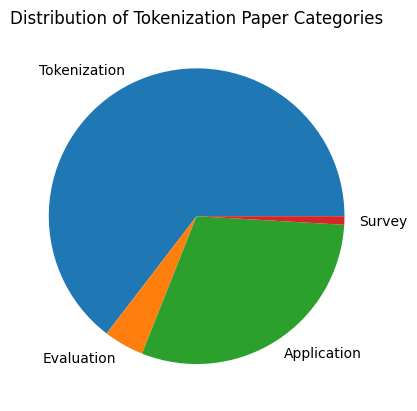

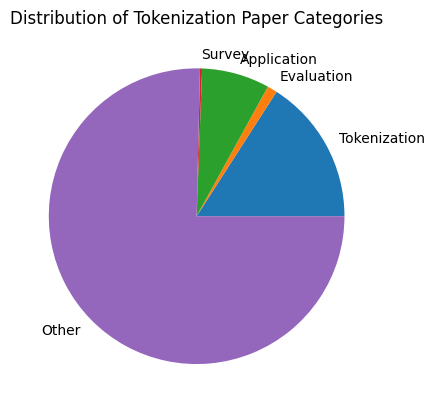

In [98]:
category_counts = {
    'Tokenization': real_tokenization['tokenization'].sum(),
    'Evaluation': real_tokenization['evaluation'].sum(),
    'Application': real_tokenization['application'].sum(),
    'Survey': real_tokenization['survey'].sum()
}
plt.figure()
plt.pie(category_counts.values(), labels=category_counts.keys())
plt.title('Distribution of Tokenization Paper Categories')
plt.show()

category_counts['Other'] = (df['topic'] == False).sum()
plt.figure()
plt.pie(category_counts.values(), labels=category_counts.keys())
plt.title('Distribution of Tokenization Paper Categories')
plt.show()

In [99]:
for i,j in category_counts.items():
    print(f"{i}: {j}")

Tokenization: 1322
Evaluation: 90
Application: 616
Survey: 19
Other: 6262


In [107]:
print("tokenization=True, evaluation=True, survey=True:", real_tokenization[(real_tokenization['tokenization'] == True) & (real_tokenization['evaluation'] == True) & (real_tokenization['survey'] == True)].shape[0])
print("tokenization=True, evaluation=True, survey=False:", real_tokenization[(real_tokenization['tokenization'] == True) & (real_tokenization['evaluation'] == True) & (real_tokenization['survey'] == False)].shape[0])
print("tokenization=True, evaluation=False, survey=True:", real_tokenization[(real_tokenization['tokenization'] == True) & (real_tokenization['evaluation'] == False) & (real_tokenization['survey'] == True)].shape[0])
print("tokenization=True, evaluation=False, survey=False:", real_tokenization[(real_tokenization['tokenization'] == True) & (real_tokenization['evaluation'] == False) & (real_tokenization['survey'] == False)].shape[0])
print("tokenization=False, evaluation=True, survey=True:", real_tokenization[(real_tokenization['tokenization'] == False) & (real_tokenization['evaluation'] == True) & (real_tokenization['survey'] == True)].shape[0])
print("tokenization=False, evaluation=True, survey=False:", real_tokenization[(real_tokenization['tokenization'] == False) & (real_tokenization['evaluation'] == True) & (real_tokenization['survey'] == False)].shape[0])
print("tokenization=False, evaluation=False, survey=True:", real_tokenization[(real_tokenization['tokenization'] == False) & (real_tokenization['evaluation'] == False) & (real_tokenization['survey'] == True)].shape[0])
print("tokenization=False, evaluation=False, survey=False:", real_tokenization[(real_tokenization['tokenization'] == False) & (real_tokenization['evaluation'] == False) & (real_tokenization['survey'] == False)].shape[0])

tokenization=True, evaluation=True, survey=True: 3
tokenization=True, evaluation=True, survey=False: 23
tokenization=True, evaluation=False, survey=True: 8
tokenization=True, evaluation=False, survey=False: 1288
tokenization=False, evaluation=True, survey=True: 6
tokenization=False, evaluation=True, survey=False: 58
tokenization=False, evaluation=False, survey=True: 2
tokenization=False, evaluation=False, survey=False: 616


In [101]:
real_tokenization.to_json('data/real_tokenization.jsonl', orient='records', lines=True)

## Mark papers with errors and split the dataset

Errors can be pdf no longer available, missing pdf (1 case), pdf encoded as image or not text extracted.
We decide an arbitrary threshold on the Markdown file size (5kb) to filter out papers with no text extracted. This excludes 9 papers, however, papers with small size are often not relevant or are just extended abstracts.

In [119]:
import tqdm
import llm_filter
import paper_dataset
import importlib
import matplotlib.pyplot as plt
import re
import json
import os
tqdm.tqdm.pandas()

In [105]:
real_tokenization = paper_dataset.load('data/real_tokenization.jsonl')
real_tokenization.shape

(2004, 18)

In [114]:
errors = {
    'tokenization': [],
    'evaluation': [],
    'application': [],
    'survey': []
}

for row in tqdm.tqdm(real_tokenization.iloc, total=len(real_tokenization)):
    try:
        paper_dataset.get_markdown(row['pdf_url'])
    except (ValueError, paper_dataset.pymupdf4llm.pymupdf.FileDataError) as e:
        if row['tokenization']:
            errors['tokenization'].append((row['bibtex_id'], row['pdf_url']))
        if row['evaluation']:
            errors['evaluation'].append((row['bibtex_id'], row['pdf_url']))
        if row['application']:
            errors['application'].append((row['bibtex_id'], row['pdf_url']))
        if row['survey']:
            errors['survey'].append((row['bibtex_id'], row['pdf_url']))
with open('data/missing_papers.json', 'w') as f:
    json.dump(errors, f, indent=2)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2004/2004 [01:03<00:00, 31.65it/s]


In [121]:
missing_urls = list(set.union(*(set(value) for value in errors.values())))
print('Missing:', len(missing_urls))
for e in errors.items():
    print(f"{e[0]}: {len(set(e[1]))}")

Missing: 57
tokenization: 39
evaluation: 4
application: 15
survey: 1


In [116]:
def too_small(x, threshold=5_000, root='data/pdfs/'):
    md = os.path.join(root, paper_dataset.pdf_url_to_file(x) + '.md')
    return (not os.path.exists(md)) or (os.path.getsize(md) < threshold)

In [120]:
real_tokenization['exclude'] = real_tokenization['pdf_url'].apply(lambda x: x == '' or x in missing_urls or too_small(x))
real_tokenization['exclude'].sum()

np.int64(62)

In [122]:
real_tokenization.to_json('data/real_tokenization.jsonl', orient='records', lines=True)

## Code

In [1]:
import tqdm
import llm_filter
import paper_dataset
import importlib
import matplotlib.pyplot as plt
import re
import json
import os
tqdm.tqdm.pandas()

/lnet/work/people/vico/TokSurvey/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


INFO 11-07 15:57:41 [__init__.py:216] Automatically detected platform cuda.


In [2]:
real_tokenization = paper_dataset.load('data/real_tokenization.jsonl')

In [3]:
def f(x: str):
    if x is None or x == '':
        return False
    try:
        md = paper_dataset.get_markdown(x)
    except (ValueError, paper_dataset.pymupdf4llm.pymupdf.FileDataError):
        return False
    if md is None:
        return False
    return llm_filter.has_pypi(md) or llm_filter.has_repository(md)
real_tokenization['has_code'] = real_tokenization['pdf_url'].progress_apply(f) & ~real_tokenization['exclude']
print(
    real_tokenization['has_code'].sum(),
    'papers with code out of', 
    len(real_tokenization),
    f"({real_tokenization['has_code'].sum()/len(real_tokenization)*100:.1f}%)"
)

  0%|                                                                                                                              | 0/2004 [00:00<?, ?it/s]

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2004/2004 [00:37<00:00, 53.35it/s]

1079 papers with code out of 2004 (53.8%)


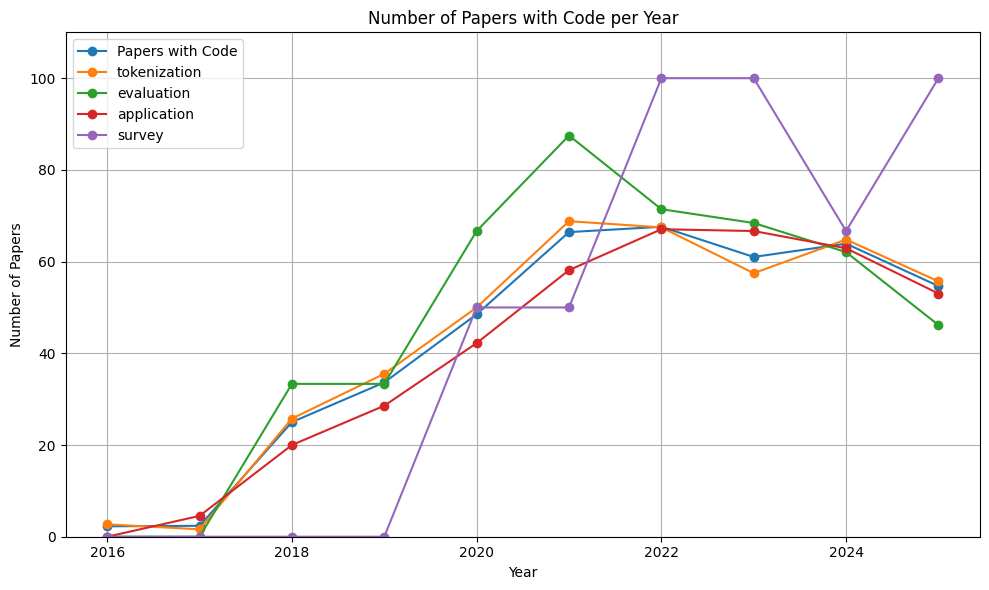

In [4]:
# Plot the number of papers with code over the years
years = sorted(real_tokenization['year'].unique())
code_counts = []
total_counts = []       
plt.figure(figsize=(10, 6))

for year in years:  
    year_data = real_tokenization[real_tokenization['year'] == year]
    code_count = year_data[year_data['has_code'] == True].shape[0]
    total_count = year_data.shape[0]
    code_counts.append(code_count)
    total_counts.append(total_count)
plt.plot(years, [c/t * 100 if t != 0 else 0 for c, t in zip(code_counts, total_counts)], marker='o', label='Papers with Code')

for cat in ['tokenization', 'evaluation', 'application', 'survey']:
    code_counts = []
    total_counts = []  
    for year in years:
        year_data = real_tokenization[(real_tokenization[cat]) & (real_tokenization['year'] == year)]
        code_count = year_data[year_data['has_code'] == True].shape[0]
        total_count = year_data.shape[0]
        code_counts.append(code_count)
        total_counts.append(total_count)
    plt.plot(years, [c/t * 100 if t != 0 else 0 for c, t in zip(code_counts, total_counts)], marker='o', label=cat)


plt.title('Number of Papers with Code per Year')
plt.xlabel('Year')
plt.ylabel('Number of Papers')
plt.ylim(0, 110)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
real_tokenization.to_json('data/real_tokenization.jsonl', orient='records', lines=True)

## Units

In [21]:
import tqdm
import llm_filter
import paper_dataset
import importlib
import matplotlib.pyplot as plt
import re
import json
import os
tqdm.tqdm.pandas()

In [95]:
importlib.reload(llm_filter)

<module 'llm_filter' from '/lnet/work/people/vico/TokSurvey/llm_filter.py'>

In [23]:
real_tokenization = paper_dataset.load('data/real_tokenization.jsonl')
real_tokenization.shape

(2004, 20)

In [ ]:
all_answers_unit = []
for answer in llm_filter.get_units(real_tokenization):
    all_answers_unit.append(answer)
    
with open('data/raw_answers/unit_answer.json', 'wt') as f:
    json.dump(all_answers_unit, f, indent=2)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1348/1348 [4:25:32<00:00, 11.82s/it]


In [ ]:
def clean_unit(units):
    clean = []
    for unit in units:
        unit = unit.lower().strip()
        if unit == "unicode characters":
            clean.append("characters")
        elif unit == "token":
            clean.append("tokens")
        elif unit == "subword tokens":
            clean.append("subwords")
        elif unit == "subword":
            clean.append("subwords")
        elif unit == "character":
            clean.append("characters")
        elif unit == "morpheme":
            clean.append("morphemes")
        elif "\n" in unit or ")" in unit:
            pass
        else:
            clean.append(unit)
    return clean

In [ ]:
with open('data/raw_answers/unit_answer.json') as f:
    all_answers_unit = json.load(f)
all_answers_unit[:5]

In [ ]:
unit_sets = [llm_filter.extract_units(i) for i in all_answers_unit]

## Metrics

In [17]:
import tqdm
import llm_filter
import paper_dataset
import importlib
import matplotlib.pyplot as plt
import re
import json
import os
tqdm.tqdm.pandas()

In [54]:
importlib.reload(llm_filter)

<module 'llm_filter' from '/lnet/work/people/vico/TokSurvey/llm_filter.py'>

In [19]:
real_tokenization = paper_dataset.load('data/real_tokenization.jsonl')
real_tokenization.shape

(2004, 20)

In [ ]:
all_answers_metric = []
for answer in llm_filter.get_units(real_tokenization):
    all_answers_metric.append(answer)
    
with open('data/raw_answers/metric_answer.json', 'wt') as f:
    json.dump(all_answers_metric, f, indent=2)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2004/2004 [16:34:18<00:00, 29.77s/it]


In [ ]:
with open('data/raw_answers/metric_answer.json') as f:
    all_answers_metric = json.load(f)
all_answers_metric[:5]

## Motivations

In [ ]:
import tqdm
import llm_filter
import paper_dataset
import importlib
import matplotlib.pyplot as plt
import re
import json
import os
tqdm.tqdm.pandas()

In [42]:
importlib.reload(llm_filter)

<module 'llm_filter' from '/lnet/work/people/vico/TokSurvey/llm_filter.py'>

In [ ]:
real_tokenization = paper_dataset.load('data/real_tokenization.jsonl')
real_tokenization.shape

In [ ]:
all_answers_motivation = []
for answer in llm_filter.get_units(real_tokenization):
    all_answers_motivation.append(answer)
    
with open('data/raw_answers/motivation_answer.json', 'wt') as f:
    json.dump(all_answers_motivation, f, indent=2)

In [ ]:
with open('data/raw_answers/motivation_answer.json') as f:
    all_answers_motivation = json.load(f)
all_answers_motivation[:5]

## Languages

In [ ]:
import tqdm
import llm_filter
import paper_dataset
import importlib
import matplotlib.pyplot as plt
import re
import json
import os
tqdm.tqdm.pandas()

In [ ]:
importlib.reload(llm_filter)

In [ ]:
real_tokenization = paper_dataset.load('data/real_tokenization.jsonl')
real_tokenization.shape

In [ ]:
all_answers_languages = []
for answer in llm_filter.get_units(real_tokenization):
    all_answers_languages.append(answer)
    
with open('data/raw_answers/language_answer.json', 'wt') as f:
    json.dump(all_answers_languages, f, indent=2)

In [ ]:
with open('data/raw_answers/language_answer.json') as f:
    all_answers_languages = json.load(f)
all_answers_languages[:5]

## Evaluation papers

- Papers over the years
- LLM: languages, motivation
- github / usable github


In [1]:
import importlib
import llm_filter
import pandas as pd
import paper_dataset
import tqdm
import iso639
import json
tqdm.tqdm.pandas()

/home/vico/personal_work_ms/TokSurvey/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


INFO 09-29 15:32:57 [__init__.py:220] No platform detected, vLLM is running on UnspecifiedPlatform
WARNING 09-29 15:32:59 [_custom_ops.py:20] Failed to import from vllm._C with ImportError('libcuda.so.1: cannot open shared object file: No such file or directory')


In [2]:
evaluation = pd.read_json('data/selected_tokenization_papers.jsonl', lines=True)
evaluation = evaluation[(evaluation['exclude'] == False) & (evaluation['evaluation'] == True)]
evaluation.shape

(173, 21)

In [ ]:
def exclusive_english(item):
    md = paper_dataset.get_markdown(item['pdf_url'])
    title = item['title'] if item['title'] is not None else ''
    answer = llm_filter.judge(llm_filter.SYSTEM_PROMPT_LANGUAGE, llm_filter.USER_PROMPT_LANGUAGE_EN, {'title': title, 'content': md}, local=True)
    return answer.lower().strip().startswith("yes")

def languages(item):
    md = paper_dataset.get_markdown(item['pdf_url'])
    title = item['title'] if item['title'] is not None else ''
    answer = llm_filter.judge(llm_filter.SYSTEM_PROMPT_LANGUAGE, llm_filter.USER_PROMPT_LANGUAGE_MULTILINGUAL, {'title': title, 'content': md}, local=True, max_tokens=1024)
    langs = llm_filter.extract_languages(answer)
    return langs, answer

In [2]:
# evaluation['exclusive_english'] = evaluation.progress_apply(exclusive_english, axis=1)
# all_answers = []
# all_langs = []
# for item in tqdm.tqdm(evaluation.iloc):
#     codes, answer = languages(item)
#     all_answers.append(answer)
#     all_langs.append(codes)
# with open('evaluation_language_answer.json', 'wt') as f:
#     json.dump(all_answers, f)

# evaluation['languages'] = all_langs
# evaluation.to_json('data/evaluation_papers.jsonl', orient='records', lines=True)
evaluation = pd.read_json('data/evaluation_papers.jsonl', lines=True)

## Add the other fields

- Based on BPE/Unigram/WordPiece/PIXEL/Tokenizer-free/Other
- Units: subword/morphemes/characters/bytes/pixels/other (x)
- Evaluation metrics (x)
- Multilingual (derived)
- Languages (x)
- Motivation 